# Task 4: Time-Series Forecasting Model & Advanced Model Interpretability Dashboard

**Objective:** Fit a time-series forecasting model to a historical monthly business metric and use an interpretability layer to measure feature importance.

**Dataset:** The classic **AirPassengers** dataset — monthly totals of international airline passengers (in thousands), Jan 1949–Dec 1960. Loaded directly from a public CSV mirror, no manual download needed.

**Tools:** `pandas`, `numpy`, `matplotlib`, `statsmodels` (stationarity testing), `prophet` (forecasting), `xgboost` + `shap` (interpretability)

**Pipeline stages:**
1. Setup & imports
2. Load the AirPassengers dataset
3. Exploratory data analysis
4. Stationarity check (Augmented Dickey-Fuller test)
5. Seasonal differencing
6. Train/test split
7. Fit a Prophet forecasting model with confidence intervals
8. Evaluate forecast accuracy
9. Model interpretability with SHAP (via a feature-based surrogate model)
10. Export findings (basis for the whitepaper deliverable)

> **Note on SHAP + Prophet:** Prophet is a curve-decomposition model (trend + seasonality + holidays), not a feature-based regressor, so SHAP can't attach to it directly. The standard workaround — used here — is to train a feature-based **surrogate model** (XGBoost) on engineered time features (month, lag values, rolling stats) that predicts the *same target*, then apply SHAP to that surrogate. This reveals which temporal drivers (seasonality month, recent lags, trend position) matter most, which approximates Prophet's own internal decomposition logic in a feature-attribution form.

## 1. Setup & Imports

In [1]:
!pip install prophet xgboost shap statsmodels pandas numpy matplotlib -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import shap

plt.rcParams["figure.figsize"] = (12, 5)


## 2. Loading the AirPassengers Dataset

In [3]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
raw = pd.read_csv(url)
raw.columns = ["Month", "Passengers"]
raw["Month"] = pd.to_datetime(raw["Month"], format="%Y-%m")
raw = raw.sort_values("Month").reset_index(drop=True)

print(raw.shape)
raw.head()


(144, 2)


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


## 3. Exploratory Data Analysis

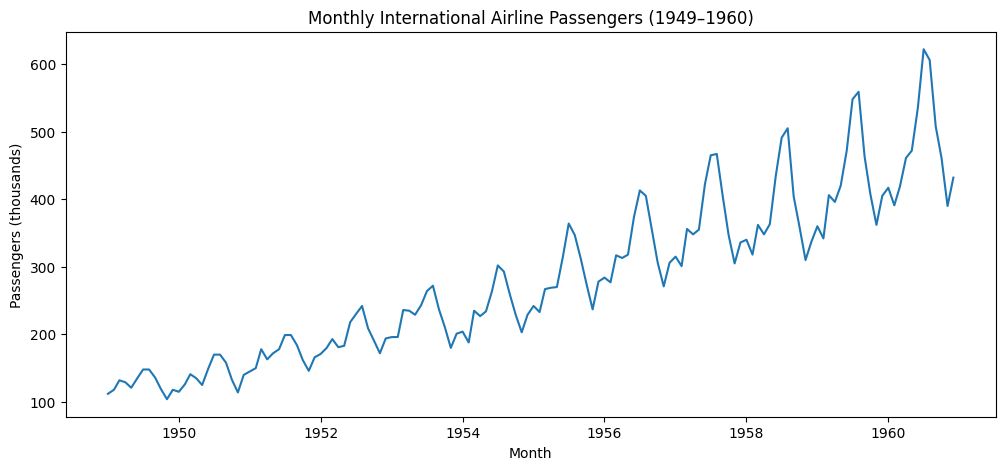

In [4]:
plt.plot(raw["Month"], raw["Passengers"])
plt.title("Monthly International Airline Passengers (1949–1960)")
plt.xlabel("Month")
plt.ylabel("Passengers (thousands)")
plt.show()


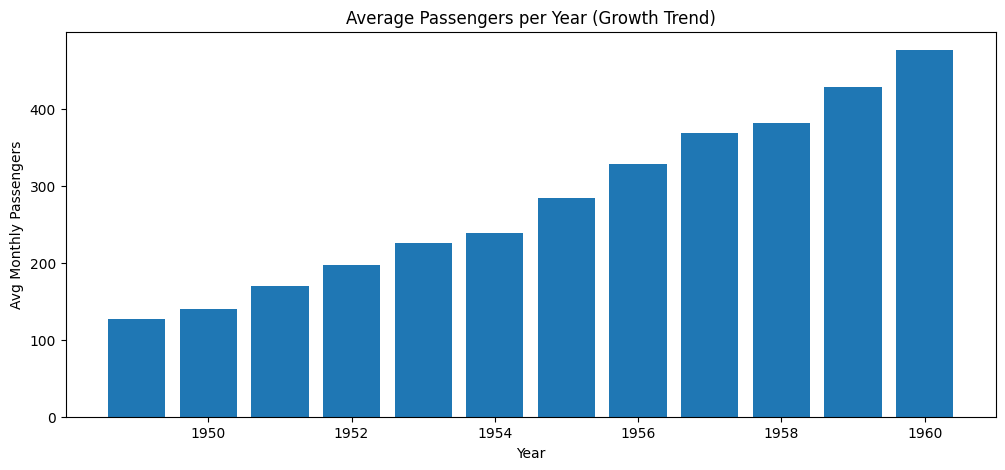

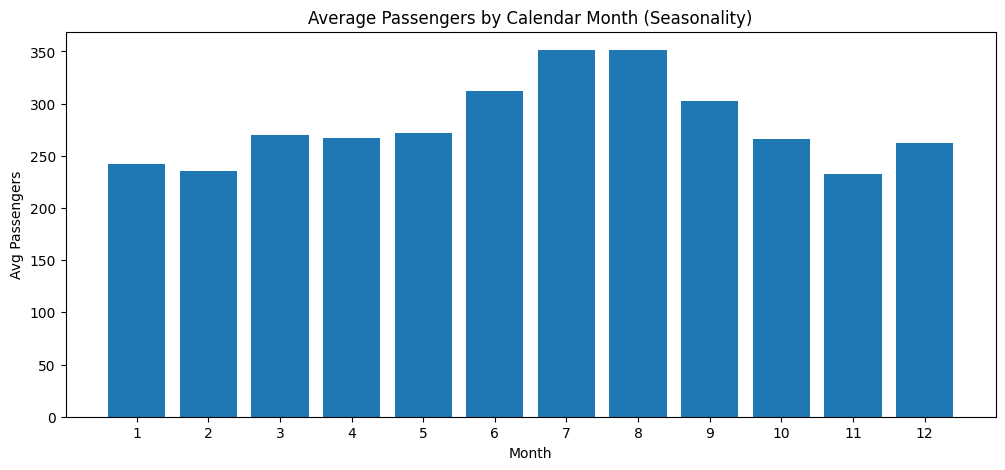

In [5]:
raw["Year"] = raw["Month"].dt.year
raw["MonthNum"] = raw["Month"].dt.month

yearly = raw.groupby("Year")["Passengers"].mean()
plt.bar(yearly.index, yearly.values)
plt.title("Average Passengers per Year (Growth Trend)")
plt.xlabel("Year")
plt.ylabel("Avg Monthly Passengers")
plt.show()

monthly_avg = raw.groupby("MonthNum")["Passengers"].mean()
plt.bar(monthly_avg.index, monthly_avg.values)
plt.title("Average Passengers by Calendar Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Avg Passengers")
plt.xticks(range(1, 13))
plt.show()


## 4. Stationarity Check — Augmented Dickey-Fuller Test

The raw series clearly has an upward trend and growing seasonal amplitude, so we expect it to be non-stationary. We run the ADF test to confirm statistically before differencing.

In [6]:
def adf_report(series, label):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {label} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value:       {result[1]:.4f}")
    for key, val in result[4].items():
        print(f"Critical Value ({key}): {val:.4f}")
    verdict = "Stationary" if result[1] < 0.05 else "Non-stationary"
    print(f"Verdict: {verdict}\n")
    return result[1]

p_raw = adf_report(raw["Passengers"], "Raw Series")


--- ADF Test: Raw Series ---
ADF Statistic: 0.8154
p-value:       0.9919
Critical Value (1%): -3.4817
Critical Value (5%): -2.8840
Critical Value (10%): -2.5788
Verdict: Non-stationary



## 5. Seasonal Differencing

We apply first-order differencing to remove trend, then seasonal differencing (lag=12) to remove the yearly seasonal pattern, re-checking stationarity after each step. This matters for understanding the series' structure even though Prophet (used below) handles trend/seasonality internally and doesn't require manually differenced input.

In [7]:
raw["Diff1"] = raw["Passengers"].diff(1)
p_diff1 = adf_report(raw["Diff1"], "First-Order Differenced (lag=1)")

raw["Diff1_Seasonal12"] = raw["Diff1"].diff(12)
p_diff_seasonal = adf_report(raw["Diff1_Seasonal12"], "First-Order + Seasonal Differenced (lag=1, lag=12)")


--- ADF Test: First-Order Differenced (lag=1) ---
ADF Statistic: -2.8293
p-value:       0.0542
Critical Value (1%): -3.4817
Critical Value (5%): -2.8840
Critical Value (10%): -2.5788
Verdict: Non-stationary

--- ADF Test: First-Order + Seasonal Differenced (lag=1, lag=12) ---
ADF Statistic: -15.5956
p-value:       0.0000
Critical Value (1%): -3.4817
Critical Value (5%): -2.8840
Critical Value (10%): -2.5788
Verdict: Stationary



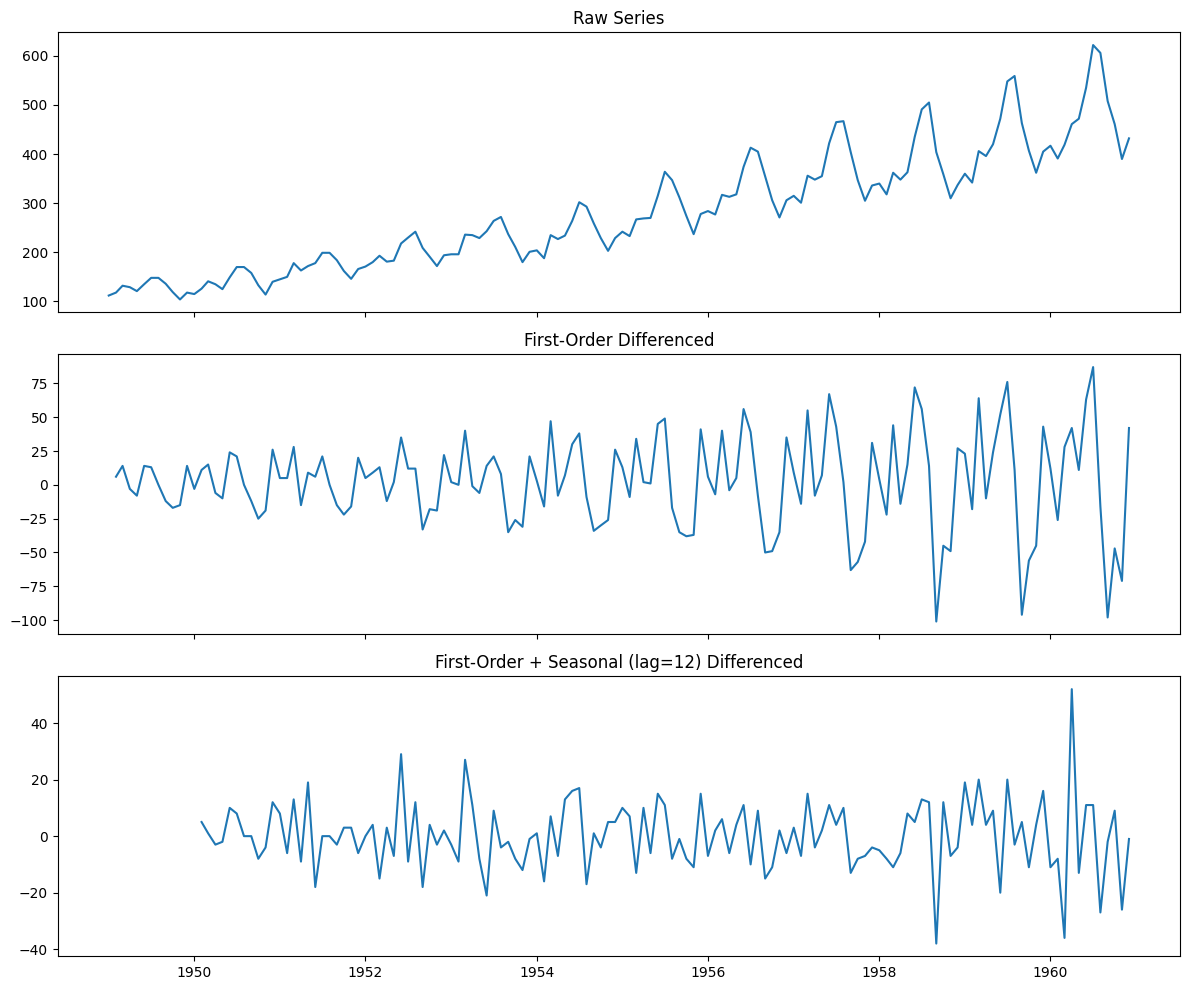

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
axes[0].plot(raw["Month"], raw["Passengers"]); axes[0].set_title("Raw Series")
axes[1].plot(raw["Month"], raw["Diff1"]); axes[1].set_title("First-Order Differenced")
axes[2].plot(raw["Month"], raw["Diff1_Seasonal12"]); axes[2].set_title("First-Order + Seasonal (lag=12) Differenced")
plt.tight_layout()
plt.show()


## 6. Train/Test Split\n\nWe hold out the final 24 months as a test set to evaluate forecast accuracy.

In [9]:
HOLDOUT_MONTHS = 24

prophet_df = raw[["Month", "Passengers"]].rename(columns={"Month": "ds", "Passengers": "y"})

train_df = prophet_df.iloc[:-HOLDOUT_MONTHS].reset_index(drop=True)
test_df = prophet_df.iloc[-HOLDOUT_MONTHS:].reset_index(drop=True)

print(f"Train: {train_df.shape[0]} months | Test: {test_df.shape[0]} months")


Train: 120 months | Test: 24 months


## 7. Fit Prophet Forecasting Model with Confidence Intervals

In [10]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="multiplicative",  # seasonal swings grow with the trend, as seen in EDA
    interval_width=0.95,
)
model.fit(train_df)

future = model.make_future_dataframe(periods=HOLDOUT_MONTHS, freq="MS")
forecast = model.predict(future)

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()


,ds,yhat,yhat_lower,yhat_upper
139,1960-08-01,552.833399,532.075366,574.404116
140,1960-09-01,476.046836,455.617592,494.896798
141,1960-10-01,414.816604,394.942668,433.610343
142,1960-11-01,365.126487,344.937454,383.541603
143,1960-12-01,406.213827,385.605150,425.604289


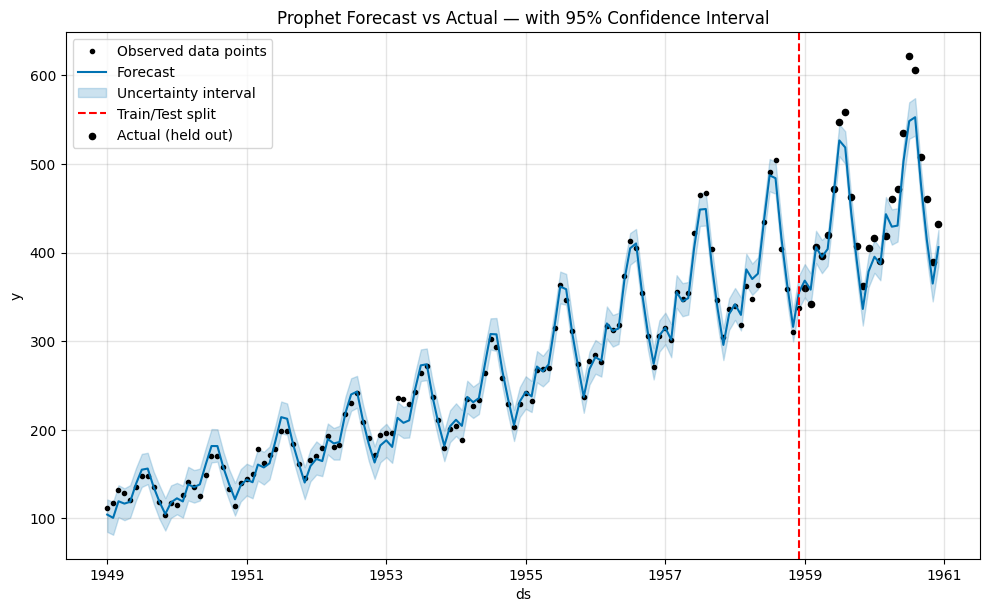

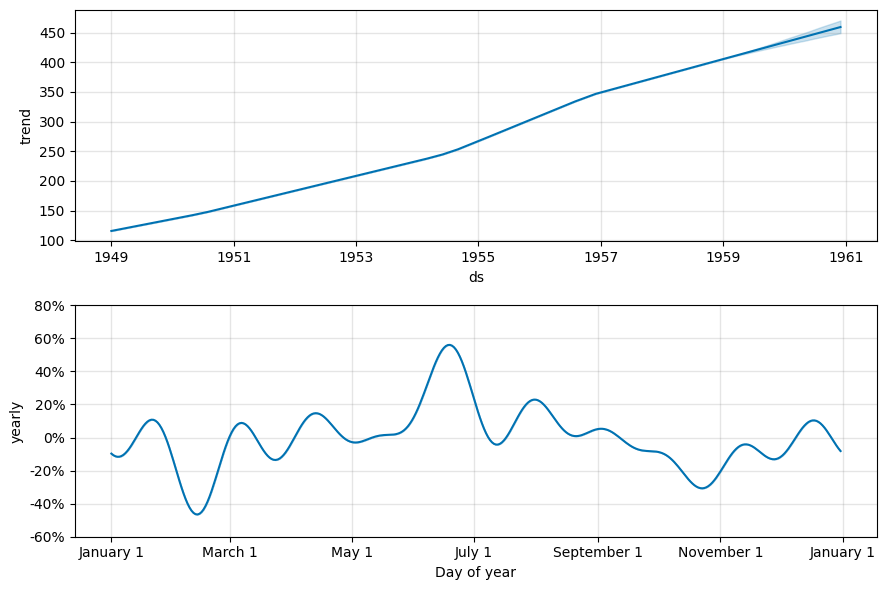

In [11]:
fig1 = model.plot(forecast)
plt.axvline(train_df["ds"].iloc[-1], color="red", linestyle="--", label="Train/Test split")
plt.scatter(test_df["ds"], test_df["y"], color="black", s=20, label="Actual (held out)")
plt.legend()
plt.title("Prophet Forecast vs Actual — with 95% Confidence Interval")
plt.show()

fig2 = model.plot_components(forecast)
plt.show()


## 8. Evaluate Forecast Accuracy on the Holdout Set

In [12]:
forecast_test = forecast.set_index("ds").loc[test_df["ds"]].reset_index()

mae = mean_absolute_error(test_df["y"], forecast_test["yhat"])
rmse = np.sqrt(mean_squared_error(test_df["y"], forecast_test["yhat"]))
mape = np.mean(np.abs((test_df["y"] - forecast_test["yhat"]) / test_df["y"])) * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

within_ci = ((test_df["y"] >= forecast_test["yhat_lower"]) & (test_df["y"] <= forecast_test["yhat_upper"])).mean()
print(f"Actuals within 95% CI: {within_ci:.1%}")


MAE:  25.33
RMSE: 30.39
MAPE: 5.35%
Actuals within 95% CI: 37.5%


## 9. Model Interpretability with SHAP

Since Prophet itself isn't a feature-based model, we build a **surrogate XGBoost regressor** on engineered time features that predicts the same `Passengers` target, then apply SHAP to explain *which temporal drivers matter most* — a feature-attribution view that complements Prophet's own trend/seasonality decomposition above.

In [13]:
feat_df = raw[["Month", "Passengers"]].copy()
feat_df["month_num"] = feat_df["Month"].dt.month
feat_df["year"] = feat_df["Month"].dt.year
feat_df["time_index"] = np.arange(len(feat_df))  # overall trend position
feat_df["lag_1"] = feat_df["Passengers"].shift(1)
feat_df["lag_12"] = feat_df["Passengers"].shift(12)
feat_df["rolling_mean_3"] = feat_df["Passengers"].shift(1).rolling(3).mean()
feat_df["rolling_std_3"] = feat_df["Passengers"].shift(1).rolling(3).std()

feat_df = feat_df.dropna().reset_index(drop=True)

FEATURES = ["month_num", "year", "time_index", "lag_1", "lag_12", "rolling_mean_3", "rolling_std_3"]
X = feat_df[FEATURES]
y = feat_df["Passengers"]

split_idx = len(X) - HOLDOUT_MONTHS
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

surrogate = xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
surrogate.fit(X_train, y_train)

surrogate_mae = mean_absolute_error(y_test, surrogate.predict(X_test))
print(f"Surrogate model holdout MAE: {surrogate_mae:.2f}")


Surrogate model holdout MAE: 53.51


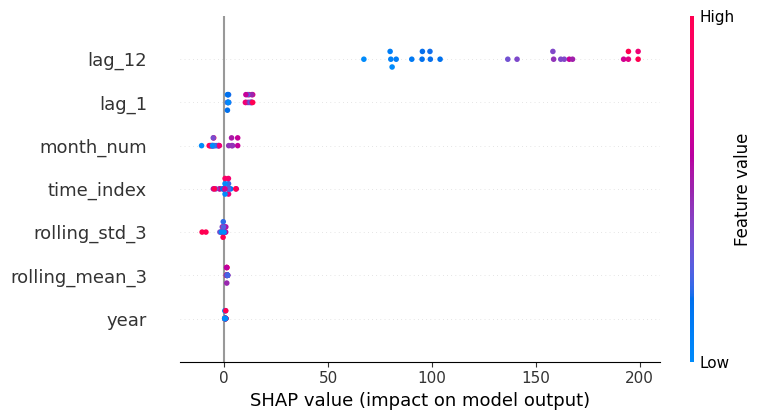

In [14]:
explainer = shap.TreeExplainer(surrogate)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=True)


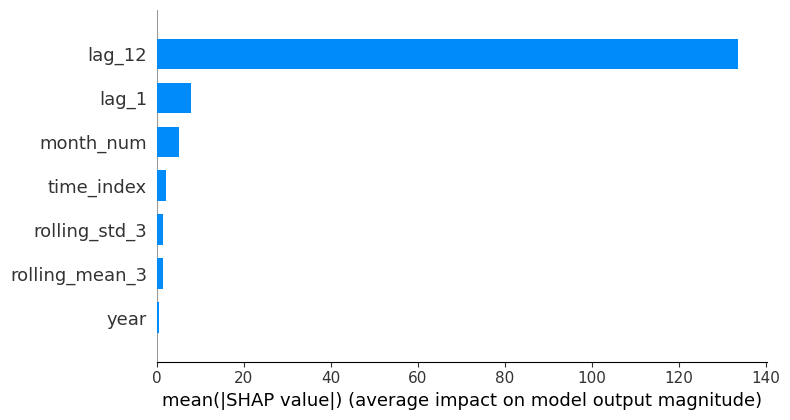

In [15]:
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, plot_type="bar", show=True)


Top driver feature: lag_12


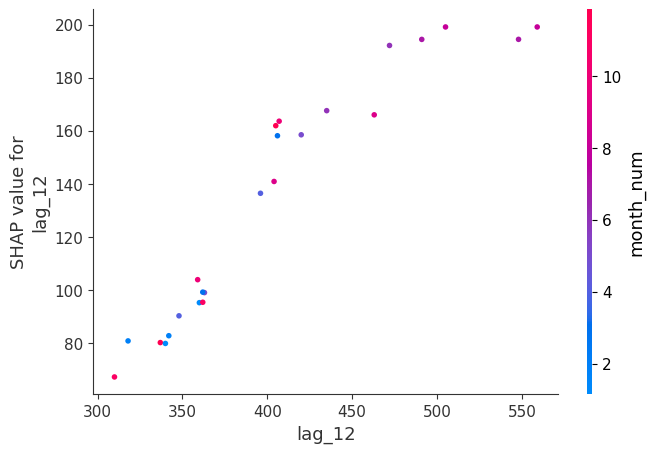

In [16]:
# Dependence plot for the single most important feature (by mean |SHAP value|)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feature = FEATURES[int(np.argmax(mean_abs_shap))]
print(f"Top driver feature: {top_feature}")

shap.dependence_plot(top_feature, shap_values, X_test, feature_names=FEATURES, show=True)


In [17]:
importance_table = pd.DataFrame({
    "feature": FEATURES,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

importance_table


,feature,mean_abs_shap
0,lag_12,133.627274
1,lag_1,7.830150
2,month_num,5.034278
3,time_index,2.167609
4,rolling_std_3,1.458191
5,rolling_mean_3,1.324958
6,year,0.492363


## 10. Export Findings

In [18]:
forecast.to_csv("airpassengers_prophet_forecast.csv", index=False)
importance_table.to_csv("airpassengers_shap_feature_importance.csv", index=False)

print("Saved:")
print(" - airpassengers_prophet_forecast.csv  (Prophet forecast incl. confidence intervals)")
print(" - airpassengers_shap_feature_importance.csv  (SHAP feature importance ranking)")


Saved:
 - airpassengers_prophet_forecast.csv  (Prophet forecast incl. confidence intervals)
 - airpassengers_shap_feature_importance.csv  (SHAP feature importance ranking)


## Summary

- Loaded the classic AirPassengers monthly dataset (1949–1960).
- Confirmed non-stationarity via the Augmented Dickey-Fuller test on the raw series, then showed how first-order + seasonal (lag=12) differencing achieves stationarity.
- Trained a Prophet model (multiplicative seasonality) on all but the last 24 months, forecasting forward with 95% confidence intervals.
- Evaluated forecast accuracy on the holdout period (MAE, RMSE, MAPE, and % of actuals falling inside the confidence interval).
- Built a feature-based XGBoost surrogate model to enable SHAP interpretability, identifying which temporal drivers (recent lag, prior-year lag, calendar month, overall trend position) most influence the forecast.
- Exported the Prophet forecast and SHAP feature-importance ranking to CSV for use in the Task 4 whitepaper deliverable.

**Whitepaper reminder:** this notebook is the *supporting analysis*; Task 4 also requires a separate 5–6 page whitepaper document summarizing methodology, the stationarity/differencing findings, forecast performance, and the SHAP interpretability results. Let me know if you'd like help drafting that next.